# Arctic Sea ice files 

* **Description**: Creates file of Utqiagvik data from CESM2-LE
* **Input data**: CESM2-le daily timeseries data
* **Output data**: Netcdf with data
* **Creator**: Alice DuVivier
* **Date**: September 2026

### Import Packages

In [1]:
#import utils
import xarray as xr
import numpy as np
from glob import glob
import importlib
from datetime import datetime
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cmocean

## Find point nearest Utqiagvik

In [2]:
# set latitude and longitude of Village (longitudes must be in 0-360)
name_village = 'Utqiagvik'
lat_village = 71.29
lon_village = 203.21
#longitue = -156.79

In [3]:
# set a dataset to read in to get grid information
dir_in = '/glade/u/home/duvivier/masks/'
file_in = 'ocn_grid_gx1v7.nc'
ds = xr.open_mfdataset(dir_in+file_in, decode_times=False)

In [4]:
# grab lat and lon data
lat2d = ds.TLAT
lon2d = ds.TLONG
land = ds.KMT

In [5]:
# First, find the index of the grid point nearest a specific lat/lon.   
abslat = np.abs(lat2d - lat_village)
abslon = np.abs(lon2d - lon_village)
c = np.maximum(abslon, abslat)

# find the smallest values
([xloc], [yloc]) = np.where(c == np.min(c))

# print index values
print(xloc,yloc)

343 205


In [6]:
# Check how close these are to the latitude and longitude of the village
print(name_village+': '+str(lat_village)+','+str(lon_village))

lat_grid = lat2d.isel(nlat=xloc,nlon=yloc).values
lon_grid = lon2d.isel(nlat=xloc,nlon=yloc).values
print('grid point: '+str(lat_grid)+','+str(lon_grid))

Utqiagvik: 71.29,203.21
grid point: 71.55580708124228,203.34041769239948


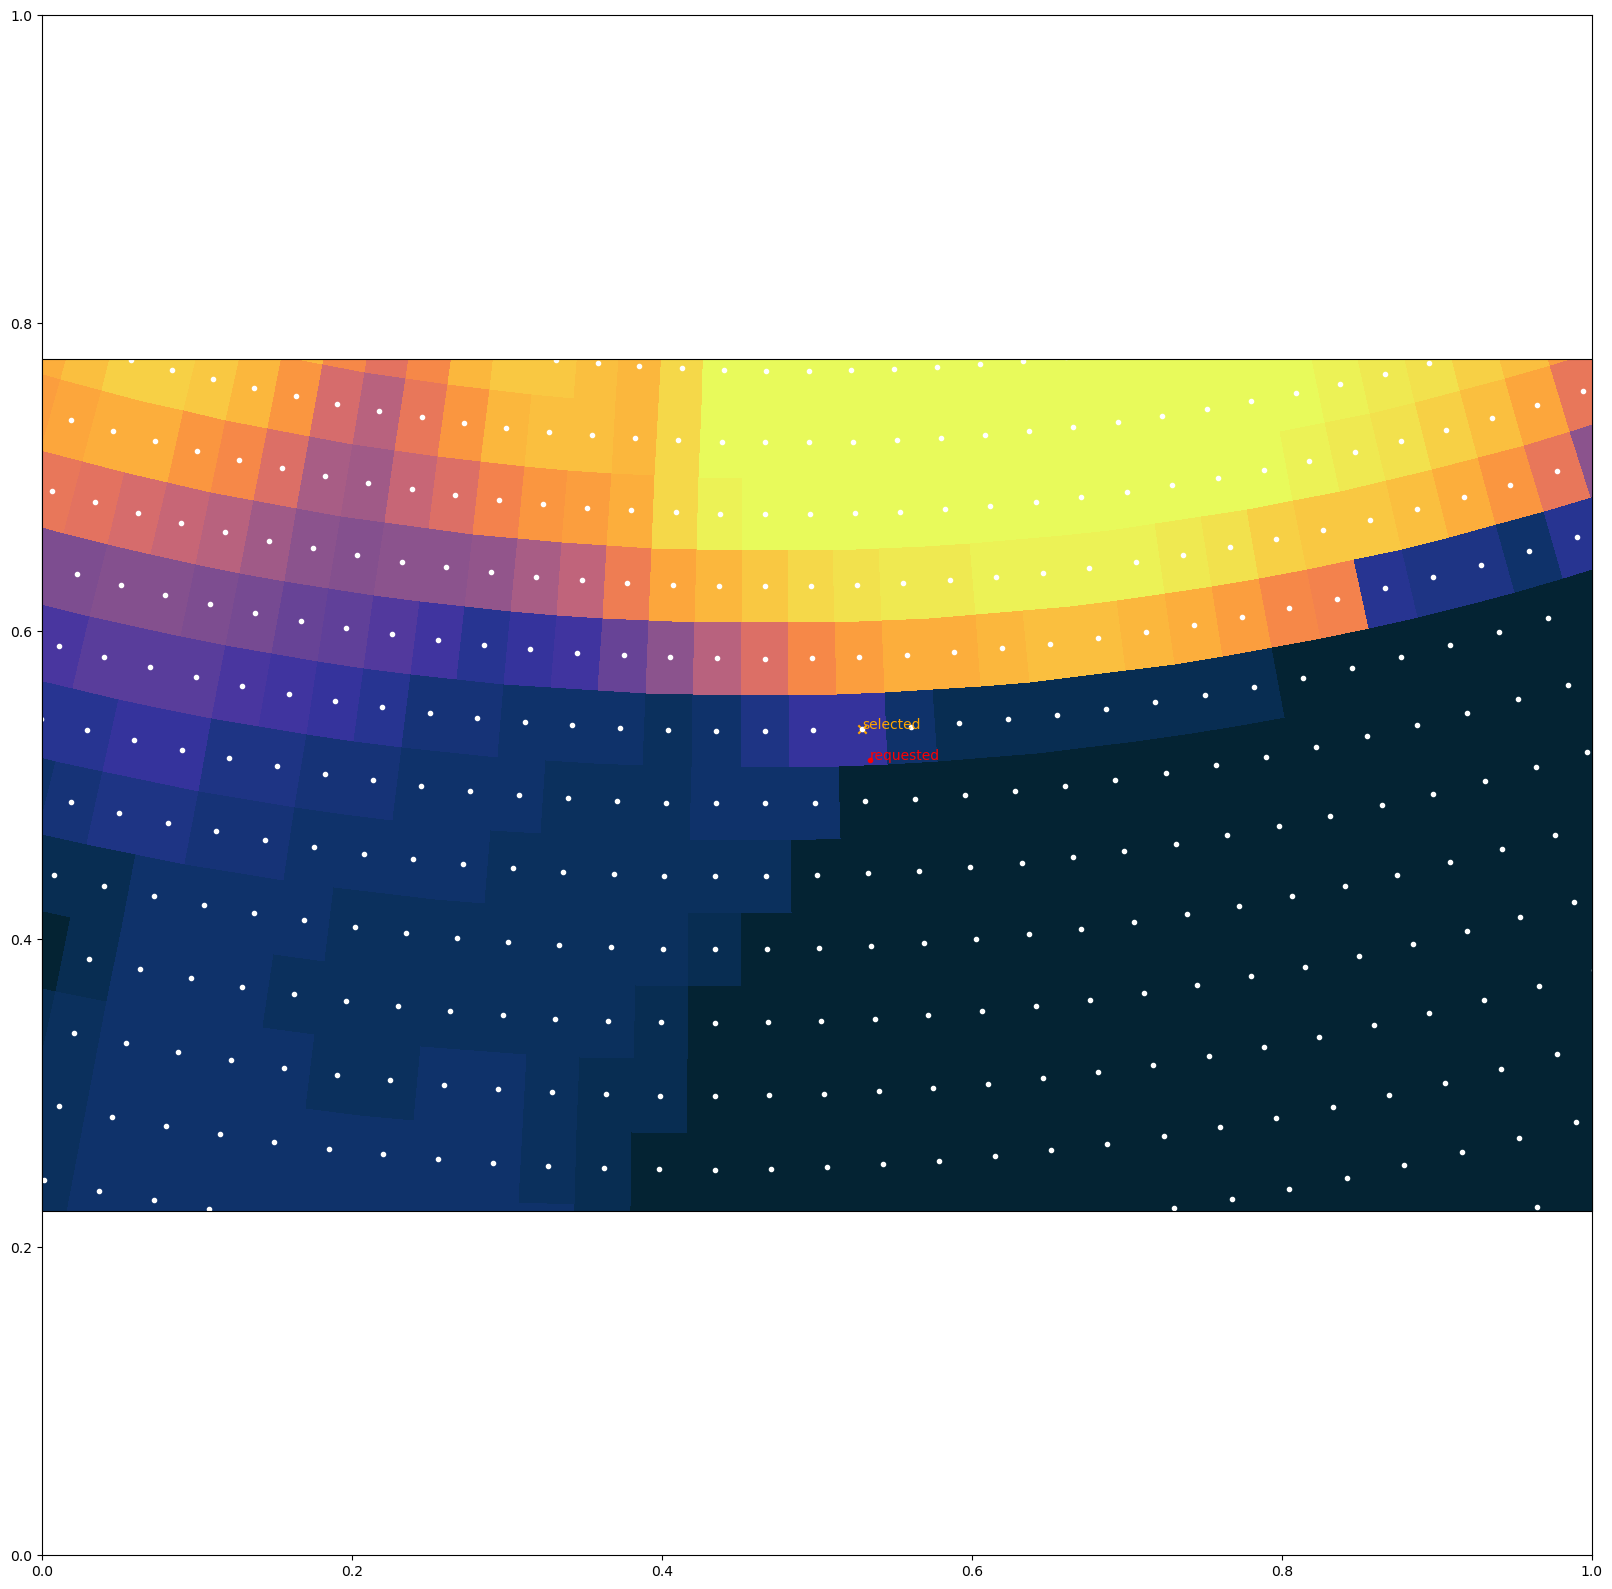

In [7]:
# Plot the Grid points to ensure we have the closest point for plots
fig = plt.figure(figsize=(20,20))

# make plot
ax = plt.subplot(1,1,1)
ax = plt.subplot(1,1,1,projection = ccrs.NorthPolarStereo(central_longitude=180.0) )
ax.set_extent([-140, -179, 72, 69], crs=ccrs.PlateCarree())

# do a pcolormesh plot of input
cs0 = ax.pcolormesh(lon2d, lat2d,
                    land,
                    cmap = cmocean.cm.thermal, vmin = 0, vmax = 50,
                    transform=ccrs.PlateCarree())

# do scatter plot of all grid values
cs1 = ax.plot(lon2d, lat2d,
                 land,
                 c='white',marker='.', linestyle='none',
                 transform=ccrs.PlateCarree())

# Plot requested lat/lon point
cs2 = ax.scatter(lon_village, lat_village, marker='.',c='red', transform=ccrs.PlateCarree())
tx1 = ax.text(lon_village, lat_village, 'requested', c='red', transform=ccrs.PlateCarree())

# Plot nearest point in the array red
cs4 = plt.scatter(lon2d.isel(nlat=xloc,nlon=yloc), lat2d.isel(nlat=xloc,nlon=yloc), marker='x', color='orange', transform=ccrs.PlateCarree())
tx2 = plt.text(lon2d.isel(nlat=xloc,nlon=yloc), lat2d.isel(nlat=xloc,nlon=yloc), 'selected', c='orange', transform=ccrs.PlateCarree())
               

- This point is an ocean point and is closest to the Utqiagvik village. Proceed!

In [8]:
# print original index values
print(xloc,yloc)

343 205


## Read in 3 CESM2 ensemble members (CMIP6 standard forcing)

In [24]:
# Select variable of interest and locate the files
# varname options = 'aice_d','hi_d'

varname = 'hi_d'
path = '/glade/campaign/collections/cmip/CMIP6/timeseries-cmip6/'

In [25]:
# list all cmip6 standard forcing ensemble numbers
ens_mems = ['b.e21.BSSP245cmip6.f09_g17.CMIP6-SSP2-4.5.101',
            'b.e21.BSSP245cmip6.f09_g17.CMIP6-SSP2-4.5.102',
            'b.e21.BSSP245cmip6.f09_g17.CMIP6-SSP2-4.5.103']

### Load future data

In [26]:
%%time

print('loading future data')
ds_ssp = xr.Dataset()

for m in ens_mems:
    print(m)

    dir_in = path + m + '/ice/proc/tseries/day_1'

    files = sorted(glob(f'{dir_in}/{m}.cice.h1.{varname}.????????-????????.nc'))
    #print(files)

    ds_tmp = xr.open_mfdataset(files, data_vars="minimal", coords='minimal', compat="override", parallel=True, 
                               concat_dim="time", combine='nested', decode_times=True)
    # take an average over the time bounds to get the right time dimension
    ds_tmp["time"] = ds_tmp.time_bounds.compute().mean(dim="d2")

    # keep only some variables
    keep_vars=['TLAT','TLONG','tarea','time'] + [varname]
    ds_tmp = ds_tmp.drop_vars([v for v in ds_tmp.variables if v not in keep_vars])
    
    ds_ssp = xr.concat([ds_ssp,ds_tmp], dim='member_id')

loading future data
b.e21.BSSP245cmip6.f09_g17.CMIP6-SSP2-4.5.101
b.e21.BSSP245cmip6.f09_g17.CMIP6-SSP2-4.5.102
b.e21.BSSP245cmip6.f09_g17.CMIP6-SSP2-4.5.103
CPU times: user 1min 18s, sys: 7.67 s, total: 1min 26s
Wall time: 2min 19s


## Edit data as needed

In [27]:
ds = ds_ssp

In [28]:
# keep only the point we're interested in near village
ds_village = ds.isel(nj=slice(xloc,xloc+1),ni=slice(yloc, yloc+1))

In [29]:
ds_subset = ds_village

In [30]:
ds_subset

<xarray.Dataset> Size: 753kB
Dimensions:  (member_id: 4, nj: 1, ni: 1, time: 31390)
Coordinates:
  * time     (time) object 251kB 2015-01-01 12:00:00 ... 2100-12-31 12:00:00
    TLAT     (nj, ni) float32 4B 71.56
Dimensions without coordinates: member_id, nj, ni
Data variables:
    tarea    (member_id, nj, ni) float32 16B dask.array<chunksize=(1, 1, 1), meta=np.ndarray>
    hi_d     (member_id, time, nj, ni) float32 502kB dask.array<chunksize=(1, 1, 1, 1), meta=np.ndarray>

In [31]:
ds_subset = ds_subset.isel(nj=0,ni=0)

In [32]:
ds_subset

<xarray.Dataset> Size: 753kB
Dimensions:  (member_id: 4, time: 31390)
Coordinates:
  * time     (time) object 251kB 2015-01-01 12:00:00 ... 2100-12-31 12:00:00
    TLAT     float32 4B 71.56
Dimensions without coordinates: member_id
Data variables:
    tarea    (member_id) float32 16B dask.array<chunksize=(1,), meta=np.ndarray>
    hi_d     (member_id, time) float32 502kB dask.array<chunksize=(1, 1), meta=np.ndarray>

In [33]:
%%time
ds_subset.load()

CPU times: user 6min 13s, sys: 13.8 s, total: 6min 26s
Wall time: 6min 25s


<xarray.Dataset> Size: 753kB
Dimensions:  (member_id: 4, time: 31390)
Coordinates:
  * time     (time) object 251kB 2015-01-01 12:00:00 ... 2100-12-31 12:00:00
    TLAT     float32 4B 71.56
Dimensions without coordinates: member_id
Data variables:
    tarea    (member_id) float32 16B nan 3.054e+09 3.054e+09 3.054e+09
    hi_d     (member_id, time) float32 502kB nan nan nan nan ... 0.0 0.0 0.0 0.0

## Save the variable
- Netcdf with variable dimension: (member_id x time)
- One netcdf per variable

In [34]:
ds_out = xr.Dataset()

ds_out[varname] = ds_subset[varname]

# change the attributes
ds_out.attrs['author'] = 'Alice DuVivier'
ds_out.attrs['date_processed'] = datetime.now().strftime('%Y-%m-%d')
ds_out.attrs['contents'] = f'Daily CESM2-LE data for ocean point nearest Utqiagvik'

ds_out

<xarray.Dataset> Size: 753kB
Dimensions:  (time: 31390, member_id: 4)
Coordinates:
  * time     (time) object 251kB 2015-01-01 12:00:00 ... 2100-12-31 12:00:00
    TLAT     float32 4B 71.56
Dimensions without coordinates: member_id
Data variables:
    hi_d     (member_id, time) float32 502kB nan nan nan nan ... 0.0 0.0 0.0 0.0
Attributes:
    author:          Alice DuVivier
    date_processed:  2026-09-03
    contents:        Daily CESM2-LE data for ocean point nearest Utqiagvik

In [35]:
# Print the dimensions
print("Dimensions:")
for dim in ds_out.dims:
    print(f"\t{dim}: {ds_out[dim].values.shape}")

# Print the coordinates
print("Coordinates:")
for coord in ds_out.coords:
    print(f"\t{coord}:")
    print(f"\t\t{ds_out.coords[coord].values}")
    
# Print the attributes
print("Attributes:")
for attr in ds_out.attrs:
    print(f"\t{attr}: {ds_out.attrs[attr]}")
    

Dimensions:
	time: (31390,)
	member_id: (4,)
Coordinates:
	TLAT:
		71.5558090209961
	time:
		[cftime.DatetimeNoLeap(2015, 1, 1, 12, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2015, 1, 2, 12, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2015, 1, 3, 12, 0, 0, 0, has_year_zero=True) ...
 cftime.DatetimeNoLeap(2100, 12, 29, 12, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2100, 12, 30, 12, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(2100, 12, 31, 12, 0, 0, 0, has_year_zero=True)]
Attributes:
	author: Alice DuVivier
	date_processed: 2026-09-03
	contents: Daily CESM2-LE data for ocean point nearest Utqiagvik


## Export and Save

In [36]:
# calculate the size of the dataset in GB
size_gb = ds_out.nbytes / (1024**3)
print(f"The dataset is approximately {size_gb:.2f} GB.")


The dataset is approximately 0.00 GB.


In [37]:
path_out = '/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-2.45_utqiagvik/'
file_out = name_village+'_CESM2-2.45_2015-2100_daily-'+varname+'.nc'
fout = path_out + file_out
print(fout)

/glade/campaign/cgd/ppc/duvivier/arctic_actionable/DATA/utqiagvik_data_all/cesm2-2.45_utqiagvik/Utqiagvik_CESM2-2.45_2015-2100_daily-hi_d.nc


In [38]:
# Export the dataset to NetCDF with all attributes and coordinates
ds_out.to_netcdf(fout)